# 02 — Histórico de Mundiales 1930-present

**Fuentes:**
- `silver.stg_wc_history` — resultados por partido (columnas: `home_team_raw`, `away_team_raw`, `home_score`, `away_score`, `wc_year`, `result`)
- `silver.stg_wc_goalscorers` — goleadores (**carga si existe**, requiere kaggle_loader)
- `silver.stg_wc_shootouts` — penales (**carga si existe**, requiere kaggle_loader)

**Origen:** Kaggle (dataset público). Carga única. Nota: `stage` siempre es NULL en esta fuente — la info de fase está en el campo `tournament` de Bronze.

**Por qué importa para el Monte Carlo:**
Lambda de Poisson de fallback para equipos sin cobertura StatsBomb.
Para equipos de CONCACAF, África y Asia sin datos WC2022/Copa/Euro,
usamos su promedio de goles/partido en WC 2014-present.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import query, null_report

sns.set_theme(style='whitegrid', palette='husl')
pd.set_option('display.max_columns', None)

## 1. Carga de datos

Cargamos `stg_wc_history` (siempre disponible) y opcionalmente goalscorers/shootouts.

In [2]:
# stg_wc_history — siempre existe
hist = query("SELECT * FROM silver.stg_wc_history ORDER BY wc_year")
print(f"stg_wc_history: {hist.shape}")
print("Columnas:", hist.columns.tolist())
hist.head(3)

stg_wc_history: (980, 12)
Columnas: ['match_date', 'home_team_raw', 'away_team_raw', 'home_team_lower', 'away_team_lower', 'home_score', 'away_score', 'tournament', 'city', 'country', 'wc_year', 'result']


,match_date,home_team_raw,away_team_raw,home_team_lower,away_team_lower,home_score,away_score,tournament,city,country,wc_year,result
0,1930-07-13,Belgium,United States,belgium,united states,0,3,FIFA World Cup,Montevideo,Uruguay,1930,away_win
1,1930-07-13,France,Mexico,france,mexico,4,1,FIFA World Cup,Montevideo,Uruguay,1930,home_win
2,1930-07-14,Brazil,Yugoslavia,brazil,yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,1930,away_win


In [4]:
# stg_wc_goalscorers y stg_wc_shootouts: pueden no existir si kaggle_loader no corrió
# Si faltan, ejecutar: python -m ingestion.kaggle_loader && python -m ingestion.bronze_to_neon --table wc_goalscorers

def safe_query(sql, table_label):
    try:
        df = query(sql)
        print(f"{table_label}: {df.shape}")
        return df
    except Exception as e:
        print(f"[AVISO] {table_label} no disponible: {e.__class__.__name__}")
        print(f"  Para cargarla: python -m ingestion.kaggle_loader")
        print(f"                 python -m ingestion.bronze_to_neon --table wc_goalscorers")
        print(f"                 uv run dbt run --profiles-dir ./dbt --select stg_wc_goalscorers")
        return pd.DataFrame()

goals = safe_query(
    "SELECT * FROM silver.stg_wc_goalscorers ORDER BY match_date, minute",
    "stg_wc_goalscorers"
)
shots = safe_query(
    "SELECT * FROM silver.stg_wc_shootouts ORDER BY match_date",
    "stg_wc_shootouts"
)

stg_wc_goalscorers: (2766, 9)
stg_wc_shootouts: (35, 7)


## 2. Estructura de stg_wc_history

**Columnas clave:**
- `home_team_raw`, `away_team_raw` — nombres como vienen de Kaggle
- `home_score`, `away_score` — resultado del partido
- `wc_year` — año del torneo (también disponible como `year`)
- `result` — `home_win` / `away_win` / `draw` (calculado por dbt)
- `stage` — siempre NULL en esta fuente (la info de fase está en Bronze pero no se preservó)

In [5]:
null_report(hist)

,nulos,pct,dtype


In [6]:
print(f"Ediciones únicas: {sorted(hist['wc_year'].unique())}")
print(f"Total partidos:   {len(hist)}")
print(f"\nResultados disponibles: {hist['result'].value_counts().to_dict()}")

Ediciones únicas: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022), np.int64(2026)]
Total partidos:   980

Resultados disponibles: {'home_win': 446, 'away_win': 312, 'draw': 222}


## 3. Goles por partido a lo largo de la historia

Promedio de goles por partido por edición:
 wc_year  avg_goals
    1930   3.888889
    1934   4.117647
    1938   4.666667
    1950   4.000000
    1954   5.384615
    1958   3.600000
    1962   2.781250
    1966   2.781250
    1970   2.968750
    1974   2.552632
    1978   2.684211
    1982   2.807692
    1986   2.538462
    1990   2.211538
    1994   2.711538
    1998   2.671875
    2002   2.515625
    2006   2.296875
    2010   2.265625
    2014   2.671875
    2018   2.640625
    2022   2.687500
    2026   2.875000


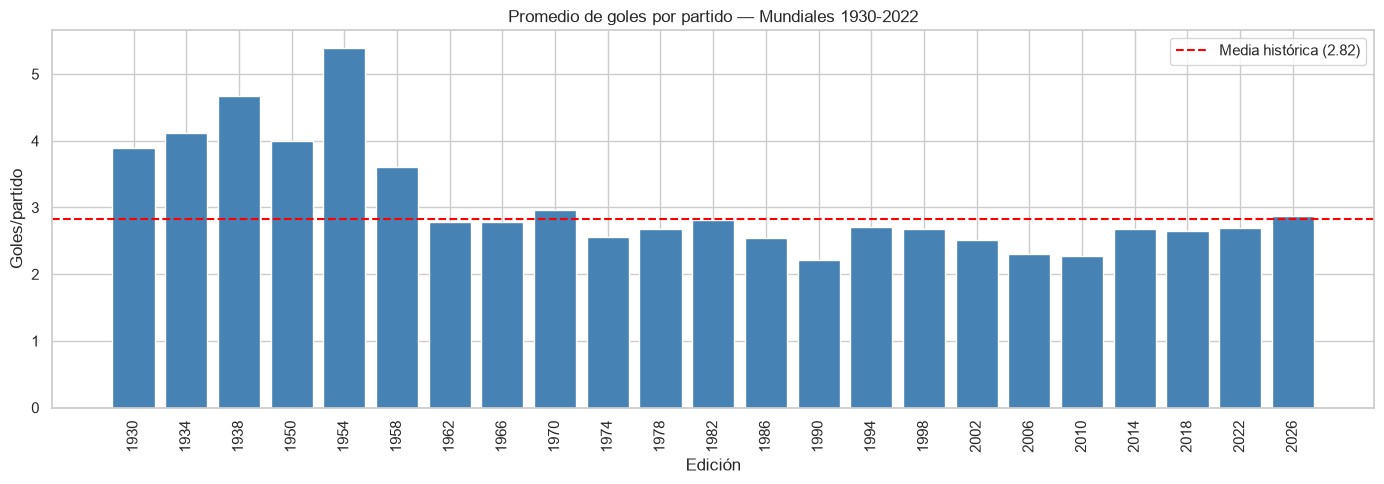


Media histórica global: 2.82 goles/partido
Últimas 3 ediciones (2014, 2018, 2022):
    wc_year  avg_goals
19     2014   2.671875
20     2018   2.640625
21     2022   2.687500
22     2026   2.875000


In [7]:
hist['total_goals'] = hist['home_score'] + hist['away_score']

goles_anio = (hist
    .groupby('wc_year')['total_goals']
    .mean()
    .reset_index()
    .rename(columns={'total_goals': 'avg_goals'}))

print("Promedio de goles por partido por edición:")
print(goles_anio.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(goles_anio['wc_year'].astype(str), goles_anio['avg_goals'], color='steelblue')
ax.axhline(hist['total_goals'].mean(), color='red', linestyle='--',
           label=f"Media histórica ({hist['total_goals'].mean():.2f})")
ax.set_title('Promedio de goles por partido — Mundiales 1930-2022')
ax.set_xlabel('Edición')
ax.set_ylabel('Goles/partido')
ax.tick_params(axis='x', rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMedia histórica global: {hist['total_goals'].mean():.2f} goles/partido")
print(f"Últimas 3 ediciones (2014, 2018, 2022):")
print(goles_anio[goles_anio['wc_year'] >= 2014])

## 4. Tasa de empates histórica

Este dato calibra el modelo Monte Carlo: ¿qué proporción de partidos terminan empate?
(Importante: en eliminatorias no hay empates en tiempo regular, solo en grupos)

In [8]:
result_dist = hist['result'].value_counts(normalize=True) * 100
print("Distribución histórica de resultados (todos los partidos):")
print(result_dist.round(1))

# Nota: stage es NULL en stg_wc_history, no podemos separar grupos de eliminatorias
# La tasa de empate incluye tanto grupos como knockout (en knockout son menos comunes)
draw_rate = result_dist.get('draw', 0)
print(f"\nTasa de empate global: {draw_rate:.1f}%")
print("Nota: incluye eliminatorias (donde el empate lleva a penales) — la tasa real en fase de grupos es mayor")

Distribución histórica de resultados (todos los partidos):
result
home_win    45.5
away_win    31.8
draw        22.7
Name: proportion, dtype: float64

Tasa de empate global: 22.7%
Nota: incluye eliminatorias (donde el empate lleva a penales) — la tasa real en fase de grupos es mayor


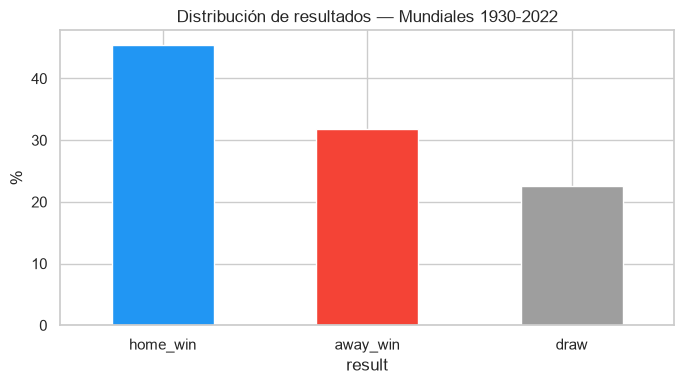

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {'home_win': '#2196F3', 'away_win': '#F44336', 'draw': '#9E9E9E'}
result_dist.plot(kind='bar', ax=ax, color=[colors.get(r, 'gray') for r in result_dist.index])
ax.set_title('Distribución de resultados — Mundiales 1930-2022')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 5. Rendimiento histórico por equipo

In [10]:
# Construir tabla de rendimiento (usando home_team_raw y away_team_raw)
home_stats = hist[['home_team_raw', 'home_score', 'away_score']].rename(
    columns={'home_team_raw': 'team', 'home_score': 'gf', 'away_score': 'gc'})
away_stats = hist[['away_team_raw', 'away_score', 'home_score']].rename(
    columns={'away_team_raw': 'team', 'away_score': 'gf', 'home_score': 'gc'})

all_team = pd.concat([home_stats, away_stats])
all_team['pts'] = all_team.apply(
    lambda r: 3 if r.gf > r.gc else (1 if r.gf == r.gc else 0), axis=1)

rendimiento = (all_team
    .groupby('team')
    .agg(pj=('gf','count'), gf=('gf','sum'), gc=('gc','sum'), pts=('pts','sum'))
    .assign(
        avg_gf=lambda d: (d['gf']/d['pj']).round(3),
        avg_gc=lambda d: (d['gc']/d['pj']).round(3)
    )
    .sort_values('pj', ascending=False)
    .head(25))

print("Top 25 equipos por partidos jugados en Mundiales históricos:")
rendimiento[['pj','gf','gc','avg_gf','avg_gc','pts']]

Top 25 equipos por partidos jugados en Mundiales históricos:


,pj,gf,gc,avg_gf,avg_gc,pts
team,,,,,,
Brazil,115,238,109,2.070,0.948,248
Germany,113,239,131,2.115,1.159,228
Argentina,88,152,101,1.727,1.148,158
Italy,83,128,77,1.542,0.928,156
England,74,104,68,1.405,0.919,118
France,73,136,85,1.863,1.164,131
Spain,68,108,75,1.588,1.103,111
Mexico,61,64,101,1.049,1.656,69
Uruguay,60,90,77,1.500,1.283,89


## 6. Lambda histórico para el Monte Carlo (Capa 2)

**Output principal de este notebook.** Lambda de Poisson de fallback para equipos
que no tienen datos StatsBomb (CONCACAF, África, Asia, etc.).

In [ ]:
# Limitar a últimas 3+ ediciones para relevancia temporal (incluye WC2026 parcial)
reciente = hist[hist['wc_year'] >= 2014]

home_r = reciente[['home_team_raw', 'home_score']].rename(
    columns={'home_team_raw': 'team', 'home_score': 'gf'})
away_r = reciente[['away_team_raw', 'away_score']].rename(
    columns={'away_team_raw': 'team', 'away_score': 'gf'})

lambda_hist = (pd.concat([home_r, away_r])
    .groupby('team')
    .agg(pj=('gf','count'), gf=('gf','sum'))
    .assign(lambda_hist=lambda d: (d['gf']/d['pj']).round(3))
    .reset_index()
    .sort_values('lambda_hist', ascending=False))

LAMBDA_GLOBAL = reciente['total_goals'].mean() / 2  # por equipo

print(f"Equipos con datos históricos (WC 2014-present): {len(lambda_hist)}")
print(f"Lambda global de fallback (media por equipo): {LAMBDA_GLOBAL:.3f}")
print()
print(lambda_hist.to_string(index=False))

## 7. Goleadores históricos (si la tabla existe)

In [13]:
if len(goals) == 0:
    print("stg_wc_goalscorers no disponible.")
    print("Para cargarla desde PowerShell (desde raiz del proyecto):")
    print("  python -m ingestion.kaggle_loader")
    print("  python -m ingestion.bronze_to_neon --table wc_goalscorers")
    print("  uv run dbt run --profiles-dir ./dbt --select stg_wc_goalscorers")
else:
    print("Columnas:", goals.columns.tolist())
    scorer_col = 'scorer' if 'scorer' in goals.columns else goals.columns[3]

    top_scorers = (goals[goals.get('own_goal', False) == False]
        .groupby(scorer_col).size()
        .sort_values(ascending=False)
        .head(20)
        .reset_index(name='goles'))

    print("Top 20 goleadores históricos:")
    print(top_scorers.to_string(index=False))

Columnas: ['match_date', 'home_team', 'away_team', 'scoring_team', 'scorer', 'minute', 'own_goal', 'penalty', 'goal_type']
Top 20 goleadores históricos:
           scorer  goles
   Miroslav Klose     16
          Ronaldo     15
      Gerd Müller     14
     Lionel Messi     13
    Just Fontaine     13
    Kylian Mbappé     12
             Pelé     12
    Sándor Kocsis     11
 Jürgen Klinsmann     11
     Gary Lineker     10
      Helmut Rahn     10
 Teófilo Cubillas     10
    Grzegorz Lato     10
Gabriel Batistuta     10
    Thomas Müller     10
          Eusébio      9
        Jairzinho      9
             Vavá      9
   Roberto Baggio      9
Ademir de Menezes      9


## 8. Hallazgos y decisiones

| Dato | Valor | Uso en Monte Carlo |
|------|-------|--------------------|
| Media goles/partido (WC 2014-present) | 2.68 | Referencia para calibrar modelo |
| Lambda global fallback (por equipo) | **1.341** | Capa 2: equipos sin StatsBomb ni historial |
| Tasa de empates global (1930-present) | **22.7%** | Benchmark de calibración del modelo |
| Equipos con lambda histórico disponible | **56** (WC 2014-present) | Cobertura Capa 2 |

**Limitación conocida:** `stage` es NULL en `stg_wc_history` (no se preservó la fase).
No podemos separar fase de grupos de eliminatorias para la tasa de empates.
Solución futura: agregar `stage` en `stg_wc_history.sql` desde la columna `tournament` del Bronze.

**Nota WC2026:** El dataset Kaggle ya incluye resultados de WC2026 (edición 2026 visible en `wc_year`).
El filtro `wc_year >= 2014` incluye los partidos jugados hasta hoy, lo que mejora el lambda histórico
de equipos como Curaçao, Bolivia y otros que aparecen en WC2026 pero no en las ediciones anteriores.